# 🚦 Urban Traffic Congestion Forecasting Using LSTM

This notebook covers the full pipeline:
1. **Data Loading & Exploration** — understand the dataset structure
2. **Preprocessing & Feature Engineering** — clean and enrich the data
3. **Congestion Classification** — label severity levels
4. **LSTM Model Training** — learn temporal traffic patterns
5. **Evaluation & Visualization** — measure and display model accuracy
6. **Real-Time Prediction Interface** — interactive forecasting dashboard

---
**Dataset:** `traffic.csv` — 48,120 hourly vehicle counts across 4 urban junctions (Nov 2015 – Jun 2017)

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as pltp
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from itertools import product
from collections import Counter


from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix,r2_score
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import time

# Plot style
pltp.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linewidth': 0.8,
    'font.family': 'monospace',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

JUNCTION_COLORS = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff']
CONGESTION_COLORS = {'Free Flow': '#3fb950', 'Moderate': '#e3b341',
                     'Heavy': '#f78166', 'Severe': '#da3633'}

MODEL_COLORS = {'ARIMA': '#8b949e', 'LSTM': '#58a6ff', 'BiLSTM': '#3fb950'}

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}')
print('✅ All libraries loaded successfully')

TensorFlow 2.21.0 | NumPy 2.4.6 | Pandas 3.0.3
✅ All libraries loaded successfully


## 2. Data Loading & Exploration

In [2]:
df = pd.read_csv('traffic.csv', parse_dates=['DateTime'])
df = df.sort_values(['Junction', 'DateTime']).reset_index(drop=True)

print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows          : {len(df):,}')
print(f'  Columns       : {list(df.columns)}')
print(f'  Junctions     : {sorted(df["Junction"].unique())}')
print(f'  Date Range    : {df["DateTime"].min().date()} → {df["DateTime"].max().date()}')
print(f'  Total Months  : {(df["DateTime"].max() - df["DateTime"].min()).days // 30}')
print(f'  Missing Values: {df.isnull().sum().sum()}')
print('=' * 55)

df.head(10)

  DATASET OVERVIEW
  Rows          : 48,120
  Columns       : ['DateTime', 'Junction', 'Vehicles', 'ID']
  Junctions     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Date Range    : 2015-11-01 → 2017-06-30
  Total Months  : 20
  Missing Values: 0


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


In [3]:
# Per-junction statistics
stats = df.groupby('Junction')['Vehicles'].agg(
    Count='count', Mean='mean', Std='std',
    Min='min', Median='median', Max='max'
).round(2)

print('\n📊 Vehicle Count Statistics by Junction\n')
print(stats.to_string())

# Note on Junction 4
j4_start = df[df['Junction']==4]['DateTime'].min()
print(f'\n⚠  Junction 4 data starts: {j4_start.date()} (4,344 records vs 14,592 for J1–J3)')


📊 Vehicle Count Statistics by Junction

          Count   Mean    Std  Min  Median  Max
Junction                                       
1         14592  45.05  23.01    5    40.0  156
2         14592  14.25   7.40    1    13.0   48
3         14592  13.69  10.44    1    11.0  180
4          4344   7.25   3.52    1     7.0   36

⚠  Junction 4 data starts: 2017-01-01 (4,344 records vs 14,592 for J1–J3)


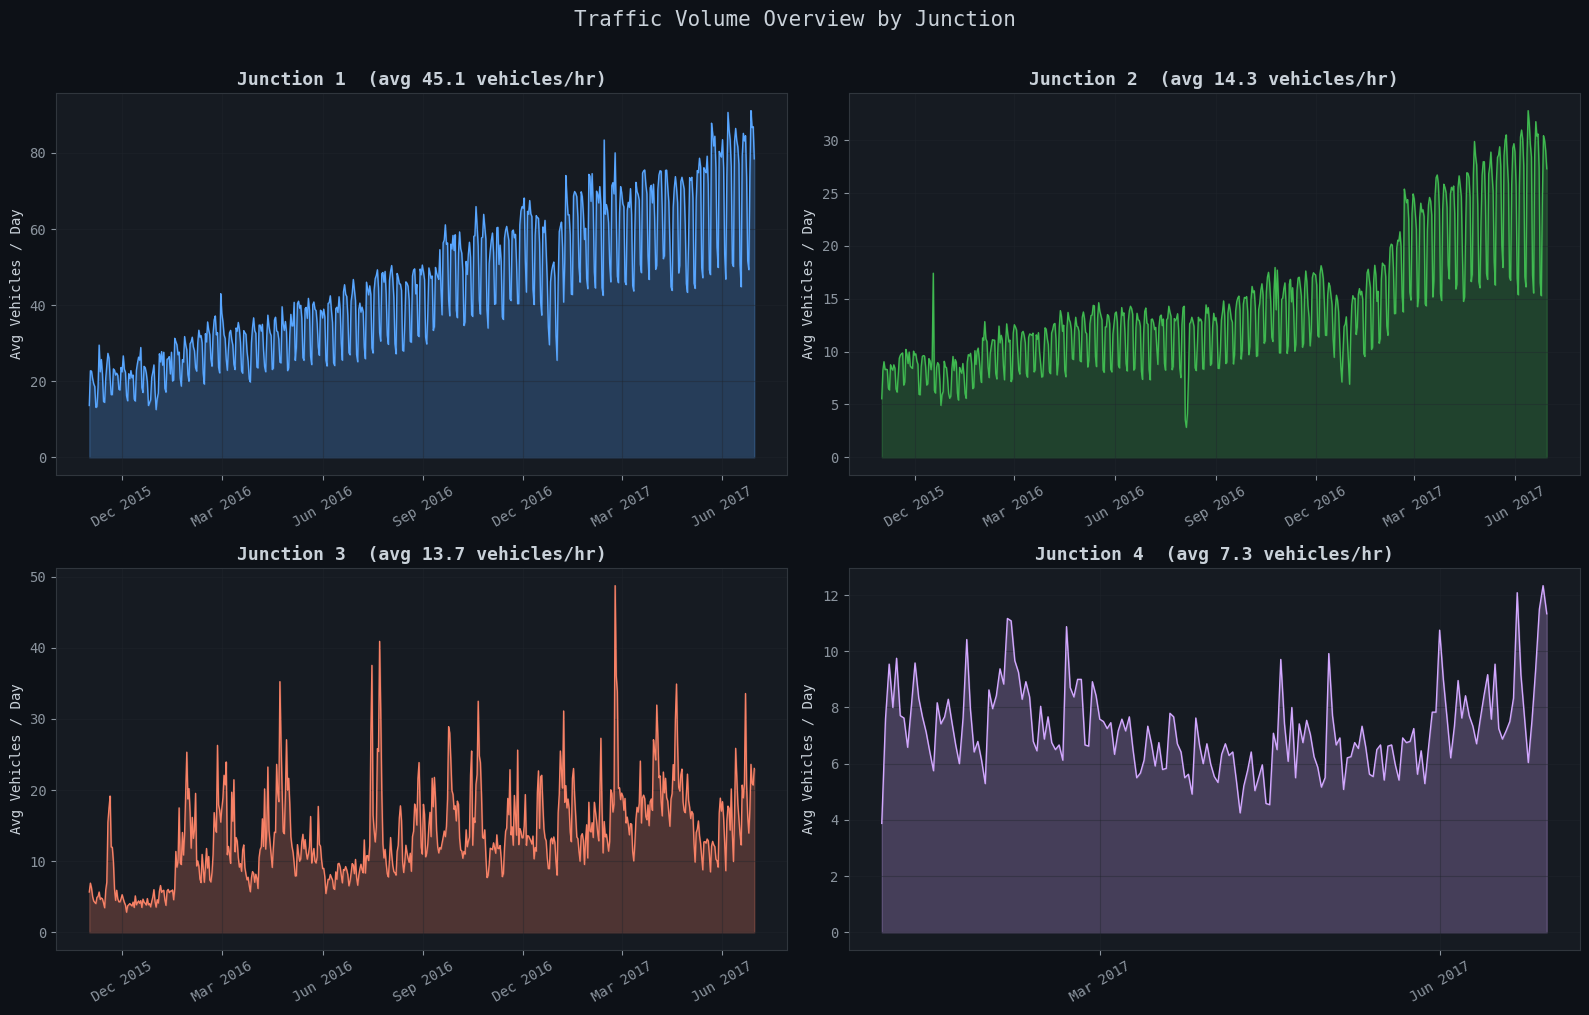

📈 Junction 1 has significantly higher volume — a major urban artery.


In [4]:
fig, axes = pltp.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Traffic Volume Overview by Junction', fontsize=15, y=1.01)

for i, (ax, junc) in enumerate(zip(axes.flat, [1, 2, 3, 4])):
    jdf = df[df['Junction'] == junc].set_index('DateTime')
    # Daily mean
    daily = jdf['Vehicles'].resample('D').mean()
    ax.fill_between(daily.index, daily.values, alpha=0.25, color=JUNCTION_COLORS[i])
    ax.plot(daily.index, daily.values, color=JUNCTION_COLORS[i], linewidth=1)
    ax.set_title(f'Junction {junc}  (avg {jdf["Vehicles"].mean():.1f} vehicles/hr)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.4)
    ax.set_ylabel('Avg Vehicles / Day')

pltp.tight_layout()
pltp.savefig('fig_overview.png', dpi=120, bbox_inches='tight')
pltp.show()
print('📈 Junction 1 has significantly higher volume — a major urban artery.')

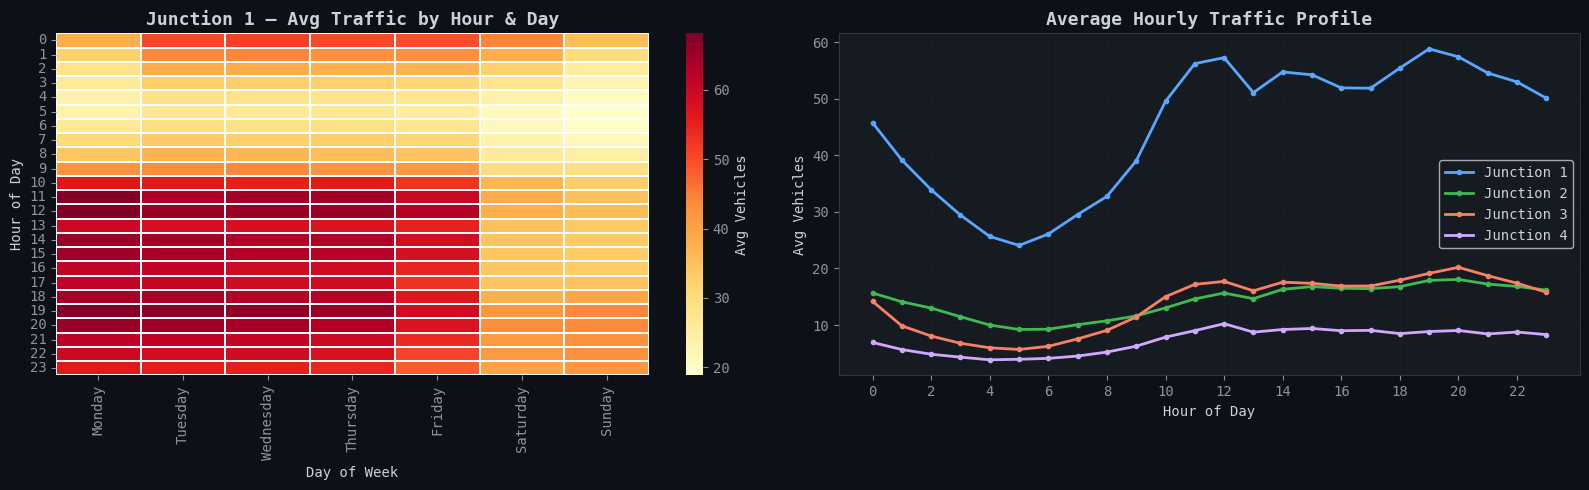

🕐 Clear morning (7–9am) and evening (5–7pm) peaks visible on weekdays.


In [5]:
fig, axes = pltp.subplots(1, 2, figsize=(16, 5))

# Heatmap: Hour vs Day of Week (Junction 1)
j1 = df[df['Junction'] == 1].copy()
j1['Hour'] = j1['DateTime'].dt.hour
j1['DayOfWeek'] = j1['DateTime'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = j1.pivot_table(values='Vehicles', index='Hour', columns='DayOfWeek', aggfunc='mean')[day_order]

sns.heatmap(pivot, ax=axes[0], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg Vehicles'}, fmt='.0f', annot=False)
axes[0].set_title('Junction 1 — Avg Traffic by Hour & Day')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Hour of Day')

# Hourly profile all junctions
for i, junc in enumerate([1, 2, 3, 4]):
    jdf = df[df['Junction'] == junc].copy()
    jdf['Hour'] = jdf['DateTime'].dt.hour
    hourly = jdf.groupby('Hour')['Vehicles'].mean()
    axes[1].plot(hourly.index, hourly.values, color=JUNCTION_COLORS[i],
                 linewidth=2, label=f'Junction {junc}', marker='o', markersize=3)
axes[1].set_title('Average Hourly Traffic Profile')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Vehicles')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
axes[1].set_xticks(range(0, 24, 2))

pltp.tight_layout()
pltp.savefig('fig_temporal.png', dpi=120, bbox_inches='tight')
pltp.show()
print('🕐 Clear morning (7–9am) and evening (5–7pm) peaks visible on weekdays.')

## 3. Feature Engineering

In [6]:
def engineer_features(df):
    df = df.copy()
    # Temporal
    df['hour']       = df['DateTime'].dt.hour
    df['dayofweek']  = df['DateTime'].dt.dayofweek          # 0=Mon
    df['month']      = df['DateTime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_peak']    = df['hour'].apply(
        lambda h: 1 if (7 <= h <= 9) or (17 <= h <= 19) else 0
    )
    # Cyclical encoding — preserves circular nature of time
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']    = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    # Lag features (per junction)
    df = df.sort_values(['Junction', 'DateTime'])
    for lag in [1, 2, 3, 24, 168]:          # 1–3h, 24h, 1 week
        df[f'lag_{lag}'] = df.groupby('Junction')['Vehicles'].shift(lag)
    # Rolling statistics
    df['roll_mean_24'] = df.groupby('Junction')['Vehicles'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=12).mean())
    df['roll_std_24']  = df.groupby('Junction')['Vehicles'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=12).std())
    df['roll_mean_6'] = df.groupby('Junction')['Vehicles'].transform(
        lambda x: x.shift(1).rolling(6,  min_periods=3).mean())
    return df

df = engineer_features(df)

print(f'Feature columns added. Total columns: {df.shape[1]}')
print('\nNew features:')
new_cols = [c for c in df.columns if c not in ['DateTime','Junction','Vehicles','ID']]
for c in new_cols:
    print(f'  • {c}')

Feature columns added. Total columns: 23

New features:
  • hour
  • dayofweek
  • month
  • is_weekend
  • is_peak
  • hour_sin
  • hour_cos
  • dow_sin
  • dow_cos
  • month_sin
  • month_cos
  • lag_1
  • lag_2
  • lag_3
  • lag_24
  • lag_168
  • roll_mean_24
  • roll_std_24
  • roll_mean_6


## 4. Congestion Classification

In [7]:
def classify_congestion(row):
    """Per-junction relative thresholds using percentiles."""
    return row['congestion_label']

# Compute junction-specific percentile thresholds
thresholds = {}
for junc in df['Junction'].unique():
    v = df[df['Junction'] == junc]['Vehicles']
    thresholds[junc] = {
        'p33': v.quantile(0.33),
        'p66': v.quantile(0.66),
        'p90': v.quantile(0.90),
    }

def label_congestion(row):
    t = thresholds[row['Junction']]
    v = row['Vehicles']
    if v <= t['p33']:   return 0  # Free Flow
    elif v <= t['p66']: return 1  # Moderate
    elif v <= t['p90']: return 2  # Heavy
    else:               return 3  # Severe

df['congestion'] = df.apply(label_congestion, axis=1)
label_map = {0: 'Free Flow', 1: 'Moderate', 2: 'Heavy', 3: 'Severe'}
df['congestion_label'] = df['congestion'].map(label_map)

print('Congestion Thresholds by Junction:')
for j, t in thresholds.items():
    print(f'  J{j}: Free<{t["p33"]:.0f} | Moderate<{t["p66"]:.0f} | Heavy<{t["p90"]:.0f} | Severe≥{t["p90"]:.0f}')

print('\nClass Distribution:')
print(df['congestion_label'].value_counts())

Congestion Thresholds by Junction:
  J1: Free<31 | Moderate<51 | Heavy<79 | Severe≥79
  J2: Free<10 | Moderate<16 | Heavy<24 | Severe≥24
  J3: Free<8 | Moderate<15 | Heavy<25 | Severe≥25
  J4: Free<5 | Moderate<8 | Heavy<12 | Severe≥12

Class Distribution:
congestion_label
Free Flow    16551
Moderate     16324
Heavy        10735
Severe        4510
Name: count, dtype: int64


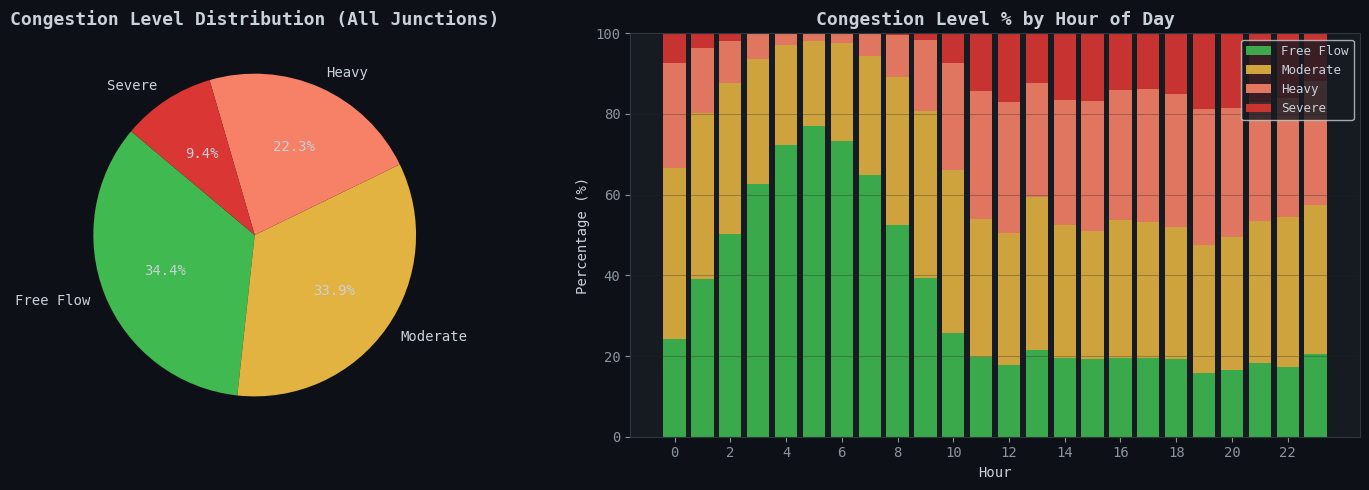

In [8]:
fig, axes = pltp.subplots(1, 2, figsize=(15, 5))

# Distribution pie
counts = df['congestion_label'].value_counts()
colors = [CONGESTION_COLORS[l] for l in counts.index]
axes[0].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'color': '#c9d1d9'})
axes[0].set_title('Congestion Level Distribution (All Junctions)')

# Congestion by hour
hourly_cong = df.groupby(['hour', 'congestion_label']).size().unstack(fill_value=0)
hourly_cong_pct = hourly_cong.div(hourly_cong.sum(axis=1), axis=0) * 100
bottom = np.zeros(24)
for label, color in CONGESTION_COLORS.items():
    if label in hourly_cong_pct.columns:
        axes[1].bar(range(24), hourly_cong_pct[label], bottom=bottom,
                   label=label, color=color, alpha=0.9)
        bottom += hourly_cong_pct[label].values
axes[1].set_title('Congestion Level % by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3, axis='y')

pltp.tight_layout()
pltp.savefig('fig_congestion.png', dpi=120, bbox_inches='tight')
pltp.show()

## 5.0.1 ARIMA BASELINE

Junction 1 clean samples: 14,424

ADF Statistic : -5.5166
p-value       : 0.0000
Stationary    : Yes ✅
Fitting ARIMA(5,1,2)…  (this may take ~30 s)
ARIMA fitted in 5.4s
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                10096
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -30458.463
Date:                Mon, 22 Jun 2026   AIC                          60932.925
Time:                        17:47:20   BIC                          60990.684
Sample:                             0   HQIC                         60952.467
                              - 10096                                         
Covariance Type:                  opg                                         
\n=============================================
  ARIMA(5,1,2) TEST METRICS — Junction 1
  MAE  : 34.80 vehicles
  RMSE : 40.09 vehicles
  R²   : -3.0115


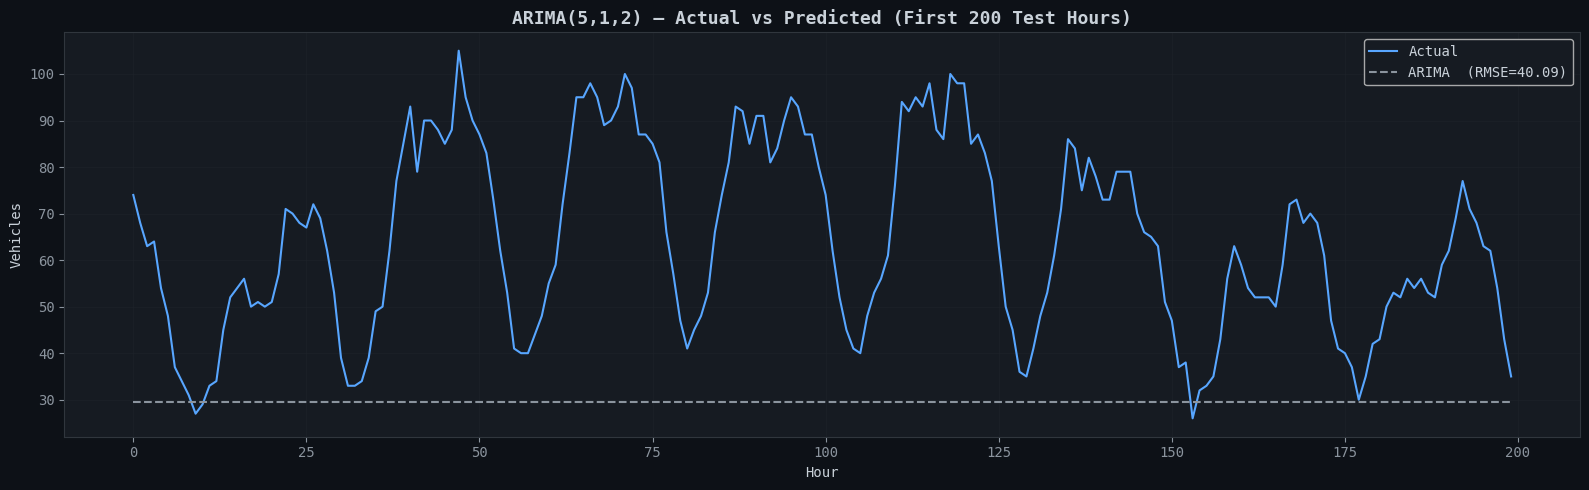

In [9]:
 
JUNCTION      = 1
SEQUENCE_LEN  = 24
FEATURE_COLS  = [
    'Vehicles',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_peak',
    'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168',
    'roll_mean_24', 'roll_std_24', 'roll_mean_6'
]

jdf = (df[df['Junction'] == JUNCTION][['DateTime'] + FEATURE_COLS]
       .dropna()
       .reset_index(drop=True))
print(f'Junction {JUNCTION} clean samples: {len(jdf):,}')

# ── Stationarity test ────────────────────────────────────────────────────────
series = jdf['Vehicles'].values
result = adfuller(series[:2000])
print(f'\nADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Stationary    : {"Yes ✅" if result[1] < 0.05 else "No — differencing needed"}')
 

# ── Chronological split (same proportions as deep learning models) ───────────
n        = len(jdf)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

vehicles_series = jdf['Vehicles'].values
train_series    = vehicles_series[:train_end]
test_series     = vehicles_series[val_end:]

# ── Fit ARIMA(5,1,2) — standard order for hourly traffic ────────────────────
print('Fitting ARIMA(5,1,2)…  (this may take ~30 s)')
t0 = time.time()
arima_model = ARIMA(train_series, order=(5, 1, 2))
arima_fit   = arima_model.fit()
print(f'ARIMA fitted in {time.time()-t0:.1f}s')
print(arima_fit.summary().tables[0])

# ── Walk-forward forecast on test set (first 200 points for speed) ───────────
N_ARIMA_TEST = 200
arima_preds  = arima_fit.forecast(steps=len(vehicles_series[train_end:val_end]) + N_ARIMA_TEST)
arima_preds  = arima_preds[len(vehicles_series[train_end:val_end]):]   # skip val portion
arima_test   = test_series[:N_ARIMA_TEST]
arima_preds  = arima_preds[:N_ARIMA_TEST]

arima_mae  = mean_absolute_error(arima_test, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(arima_test, arima_preds))
arima_r2   = r2_score(arima_test, arima_preds)

print('\\n' + '='*45)
print('  ARIMA(5,1,2) TEST METRICS — Junction 1')
print('='*45)
print(f'  MAE  : {arima_mae:.2f} vehicles')
print(f'  RMSE : {arima_rmse:.2f} vehicles')
print(f'  R²   : {arima_r2:.4f}')
print('='*45)
 

fig, ax = pltp.subplots(figsize=(16, 5))
ax.plot(range(N_ARIMA_TEST), arima_test,  color='#58a6ff', linewidth=1.5, label='Actual')
ax.plot(range(N_ARIMA_TEST), arima_preds, color='#8b949e', linewidth=1.5,
        linestyle='--', label=f'ARIMA  (RMSE={arima_rmse:.2f})')
ax.set_title('ARIMA(5,1,2) — Actual vs Predicted (First 200 Test Hours)')
ax.set_xlabel('Hour')
ax.set_ylabel('Vehicles')
ax.legend()
ax.grid(True, alpha=0.4)
pltp.tight_layout()
pltp.savefig('fig_arima.png', dpi=120, bbox_inches='tight')
pltp.show()
 



## 5. LSTM Model Preparation

In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# -----------------------------
# Scale features
# -----------------------------
scaler = MinMaxScaler()
scaled = scaler.fit_transform(jdf[FEATURE_COLS])

# -----------------------------
# Create sequences
# -----------------------------
def make_sequences(data, seq_len):
    X, y = [], []

    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])   # Vehicles column (assumed to be column 0)

    return np.array(X), np.array(y)

X, y = make_sequences(scaled, SEQUENCE_LEN)

# -----------------------------
# Train / Val / Test split
# -----------------------------
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f'Train  : {X_train.shape} → {y_train.shape}')
print(f'Val    : {X_val.shape} → {y_val.shape}')
print(f'Test   : {X_test.shape} → {y_test.shape}')
print(f'Features per step: {X_train.shape[2]}')

# -----------------------------
# Target scaler
# -----------------------------
scaler_y = MinMaxScaler()

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# -----------------------------
# Inverse transform helper
# -----------------------------
def inv_vehicles(x):
    x = np.asarray(x).reshape(-1, 1)
    return scaler_y.inverse_transform(x).flatten()

Train  : (10080, 24, 17) → (10080,)
Val    : (2160, 24, 17) → (2160,)
Test   : (2160, 24, 17) → (2160,)
Features per step: 17


## 5.1 HYPERPARAMETER TUNNING

Grid search over key LSTM hyperparameters with time-series cross-validation.
We evaluate each configuration on validation RMSE to find the optimal setup.
A lightweight search is shown here; expand `param_grid` for a full sweep.
 

In [11]:
param_grid = {
    'units_1':      [64, 128],
    'units_2':      [32],
    'dropout':      [0.1],
    'learning_rate':[0.001, 0.005],
    'batch_size':   [32, 64],
}

# Full grid combinations
all_configs = [
    dict(zip(param_grid.keys(), v))
    for v in product(*param_grid.values())
]
print(f'Total configurations: {len(all_configs)}')
print('\\nSearch space summary:')
for k, v in param_grid.items():
    print(f'  {k:20s}: {v}')
 

def build_lstm(units_1, units_2, dropout, learning_rate, n_features, seq_len):
    model = Sequential([
        LSTM(units_1, return_sequences=True,
             input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(dropout),
        LSTM(units_2, return_sequences=False),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='TunedLSTM')
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='huber', metrics=['mae'])
    return model

# ── Run the grid search (early stop after 5 patience to keep it fast) ────────
print('Running hyperparameter grid search…')
print('(Each config trains up to 20 epochs with early stopping)')
print('-' * 60)

results = []
n_features = X_train.shape[2]
ES_TUNE = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


Total configurations: 8
\nSearch space summary:
  units_1             : [64, 128]
  units_2             : [32]
  dropout             : [0.1]
  learning_rate       : [0.001, 0.005]
  batch_size          : [32, 64]
Running hyperparameter grid search…
(Each config trains up to 20 epochs with early stopping)
------------------------------------------------------------


  units=64/32  drop=0.1  lr=0.001  bs=32  → val RMSE=0.040  (104s)
  units=64/32  drop=0.1  lr=0.001  bs=64  → val RMSE=0.148  (24s)
  units=64/32  drop=0.1  lr=0.005  bs=32  → val RMSE=0.113  (28s)
  units=64/32  drop=0.1  lr=0.005  bs=64  → val RMSE=0.116  (23s)
  units=128/32  drop=0.1  lr=0.001  bs=32  → val RMSE=0.110  (42s)
  units=128/32  drop=0.1  lr=0.001  bs=64  → val RMSE=0.218  (34s)
  units=128/32  drop=0.1  lr=0.005  bs=32  → val RMSE=0.039  (65s)
  units=128/32  drop=0.1  lr=0.005  bs=64  → val RMSE=0.147  (33s)
\n============================================================
  TOP 5 CONFIGURATIONS BY VALIDATION RMSE
 units_1  units_2  dropout  learning_rate  batch_size  val_rmse  epochs  time_s
     128       32      0.1          0.005          32     0.039       8    65.1
      64       32      0.1          0.001          32     0.040      20   104.1
     128       32      0.1          0.001          32     0.110       5    42.3
      64       32      0.1          0.005 

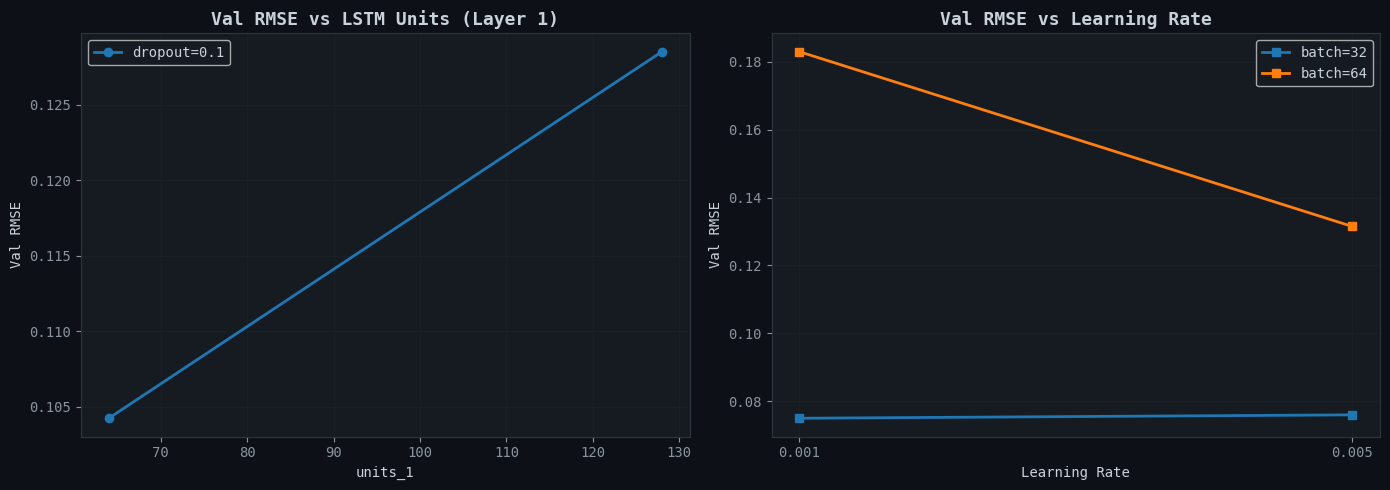

In [12]:

for cfg in all_configs:
    t0 = time.time()
    cfg_model=cfg.copy()
    batch_size=cfg_model.pop('batch_size')
    m = build_lstm(**cfg_model, 
                   n_features=n_features,
                     seq_len=SEQUENCE_LEN)
    hist = m.fit(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=20,
                 batch_size=batch_size,
                 callbacks=[ES_TUNE], verbose=0)
    val_pred = m.predict(X_val,  verbose=0).flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    elapsed  = time.time() - t0
    results.append({**cfg, 'val_rmse': round(val_rmse, 3),
                    'epochs': len(hist.history['loss']), 'time_s': round(elapsed, 1)})
    print(f"  units={cfg['units_1']}/{cfg['units_2']}  drop={cfg['dropout']}  "
          f"lr={cfg['learning_rate']}  bs={cfg['batch_size']}  "
          f"→ val RMSE={val_rmse:.3f}  ({elapsed:.0f}s)")

results_df = pd.DataFrame(results).sort_values('val_rmse')
print('\\n' + '='*60)
print('  TOP 5 CONFIGURATIONS BY VALIDATION RMSE')
print('='*60)
print(results_df.head(5).to_string(index=False))
 

# ── Extract best config ───────────────────────────────────────────────────────
best_cfg = results_df.iloc[0].to_dict()
BEST = {
    'units_1':       int(best_cfg['units_1']),
    'units_2':       int(best_cfg['units_2']),
    'dropout':       float(best_cfg['dropout']),
    'learning_rate': float(best_cfg['learning_rate']),
    'batch_size':    int(best_cfg['batch_size']),
}
print(f'\\n✅ Best Configuration:')
for k, v in BEST.items():
    print(f'   {k:20s}: {v}')
print(f'   val_rmse            : {best_cfg["val_rmse"]}')

# ── Visualise search results ──────────────────────────────────────────────────
fig, axes = pltp.subplots(1, 2, figsize=(14, 5))

# RMSE by units_1
ax = axes[0]
for dr in param_grid['dropout']:
    subset = results_df[results_df['dropout'] == dr]
    grouped = subset.groupby('units_1')['val_rmse'].mean()
    ax.plot(grouped.index, grouped.values, marker='o', linewidth=2, label=f'dropout={dr}')
ax.set_title('Val RMSE vs LSTM Units (Layer 1)')
ax.set_xlabel('units_1')
ax.set_ylabel('Val RMSE')
ax.legend()
ax.grid(True, alpha=0.4)

# RMSE by learning_rate
ax = axes[1]
for bs in param_grid['batch_size']:
    subset = results_df[results_df['batch_size'] == bs]
    grouped = subset.groupby('learning_rate')['val_rmse'].mean()
    ax.plot(grouped.index.astype(str), grouped.values, marker='s',
            linewidth=2, label=f'batch={bs}')
ax.set_title('Val RMSE vs Learning Rate')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Val RMSE')
ax.legend()
ax.grid(True, alpha=0.4)

pltp.tight_layout()
pltp.savefig('fig_hparam_search.png', dpi=120, bbox_inches='tight')
pltp.show()
 


## 6. LSTM Model Architecture & Training

In [13]:
lstm_model = Sequential([
    LSTM(BEST['units_1'], return_sequences=True,
         input_shape=(SEQUENCE_LEN, n_features)),
    BatchNormalization(),
    Dropout(BEST['dropout']),

    LSTM(BEST['units_2'], return_sequences=True),
    BatchNormalization(),
    Dropout(BEST['dropout']),

    LSTM(32, return_sequences=False),
    Dropout(0.15),

    Dense(16, activation='relu'),
    Dense(1)
], name='TrafficLSTM')

lstm_model.compile(
    optimizer=Adam(learning_rate=BEST['learning_rate']),
    loss='huber',
    metrics=['mae']
)

lstm_model.summary()

Model: "TrafficLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 24, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 24, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,865 (409.63 KB)

 Trainable params: 104,545 (408.38 KB)

 Non-trainable params: 320 (1.25 KB)

In [14]:
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1,
    batch_size=BEST['batch_size'],
    callbacks=callbacks_lstm,
    verbose=1
)
lstm_train_time = time.time() - t0
print(f'\n✅ LSTM training complete — {len(history_lstm.history["loss"])} epochs, {lstm_train_time:.0f}s')
 


315/315 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 0.0024 - mae: 0.0469 - val_loss: 0.0072 - val_mae: 0.0923 - learning_rate: 0.0050
Restoring model weights from the end of the best epoch: 1.

✅ LSTM training complete — 1 epochs, 17s


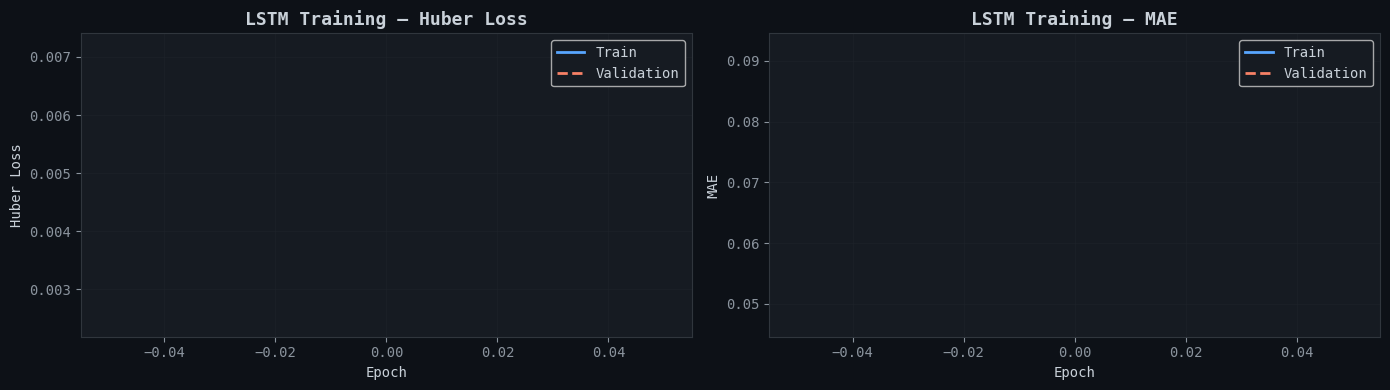

In [15]:
fig, axes = pltp.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss','mae'], ['Huber Loss','MAE']):
    ax.plot(history_lstm.history[metric],     color='#58a6ff', lw=2, label='Train')
    ax.plot(history_lstm.history[f'val_{metric}'], color='#f78166', lw=2,
            linestyle='--', label='Validation')
    ax.set_title(f'LSTM Training — {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.4)

pltp.tight_layout()
pltp.savefig('fig_lstm_training.png', dpi=120, bbox_inches='tight')
pltp.show()

## 7. Model Evaluation

In [16]:
# Inverse-transform predictions to original scale
def inverse_vehicles(scaled_vals):
    """Inverse scale the Vehicles column (col 0) only."""
    dummy = np.zeros((len(scaled_vals), len(FEATURE_COLS)))
    dummy[:, 0] = scaled_vals
    return scaler.inverse_transform(dummy)[:, 0]

y_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
y_pred = inverse_vehicles(y_pred_scaled)
y_true = inverse_vehicles(y_test)

lstm_mae   = mean_absolute_error(y_true, y_pred)
lstm_rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
lstm_mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
lstm_r2    = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_pred.mean())**2)

print('=' * 45)
print('  TEST SET EVALUATION — Junction 1')
print('=' * 45)
print(f'  MAE   : {lstm_mae:.2f} vehicles')
print(f'  RMSE  : {lstm_rmse:.2f} vehicles')
print(f'  MAPE  : {lstm_mape:.2f}%')
print(f'  R²    : {lstm_r2:.4f}')
print('=' * 45)

  TEST SET EVALUATION — Junction 1
  MAE   : 18.38 vehicles
  RMSE  : 23.54 vehicles
  MAPE  : 23.46%
  R²    : 0.3638


##  bi directional lstm model 
iLSTM processes sequences in **both directions** — forward (past→future) and
backward (future→past). The outputs are concatenated, giving the model richer
context around each time-step, especially useful for capturing symmetric
patterns like rush-hour peaks.

In [17]:
tf.random.set_seed(42)
np.random.seed(42)

bilstm_model = Sequential([
    Bidirectional(
        LSTM(BEST['units_1'], return_sequences=True),
        input_shape=(SEQUENCE_LEN, n_features)
    ),
    BatchNormalization(),
    Dropout(BEST['dropout']),

    Bidirectional(LSTM(BEST['units_2'], return_sequences=False)),
    BatchNormalization(),
    Dropout(BEST['dropout']),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
], name='TrafficBiLSTM')

bilstm_model.compile(
    optimizer=Adam(learning_rate=BEST['learning_rate']),
    loss='huber',
    metrics=['mae']
)

bilstm_model.summary()
print(f'\\nBiLSTM parameters : {bilstm_model.count_params():,}')
print(f'LSTM parameters   : {lstm_model.count_params():,}')
print(f'Overhead          : {(bilstm_model.count_params()/lstm_model.count_params()-1)*100:.1f}%  (2× units per direction)')
 

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_bilstm = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1,
    batch_size=BEST['batch_size'],
    callbacks=callbacks_bilstm,
    verbose=1
)
bilstm_train_time = time.time() - t0
print(f'\n✅ BiLSTM training complete — {len(history_bilstm.history["loss"])} epochs, {bilstm_train_time:.0f}s')
 

bilstm_pred_scaled = bilstm_model.predict(X_test, verbose=0).flatten()
bilstm_pred = inv_vehicles(bilstm_pred_scaled)

bilstm_mae  = mean_absolute_error(y_true, bilstm_pred)
bilstm_rmse = np.sqrt(mean_squared_error(y_true, bilstm_pred))
bilstm_mape = np.mean(np.abs((y_true - bilstm_pred) / (y_true + 1e-8))) * 100
bilstm_r2   = r2_score(y_true, bilstm_pred)

print('='*45)
print('  BiLSTM TEST METRICS — Junction 1')
print('='*45)
print(f'  MAE   : {bilstm_mae:.2f} vehicles')
print(f'  RMSE  : {bilstm_rmse:.2f} vehicles')
print(f'  MAPE  : {bilstm_mape:.2f}%')
print(f'  R²    : {bilstm_r2:.4f}')
print('='*45)
 


Model: "TrafficBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       149,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,393 (888.25 KB)

 Trainable params: 226,753 (885.75 KB)

 Non-trainable params: 640 (2.50 KB)

\nBiLSTM parameters : 227,393
LSTM parameters   : 104,865
Overhead          : 116.8%  (2× units per direction)
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - loss: 0.0130 - mae: 0.0865 - val_loss: 0.0127 - val_mae: 0.1302 - learning_rate: 0.0050
Restoring model weights from the end of the best epoch: 1.

✅ BiLSTM training complete — 1 epochs, 19s
  BiLSTM TEST METRICS — Junction 1
  MAE   : 68.42 vehicles
  RMSE  : 72.78 vehicles
  MAPE  : 99.68%
  R²    : -7.5966


## model comparison

  MODEL COMPARISON — Junction 1 Test Set
       Model   MAE  RMSE      R²  MAPE %  Train s
ARIMA(5,1,2) 34.80 40.09 -3.0115     NaN      NaN
        LSTM 18.38 23.54  0.3638   23.46     17.0
      BiLSTM 68.42 72.78 -7.5966   99.68     19.0
\n✅ Best model: LSTM
   RMSE improvement over ARIMA: 41.3%


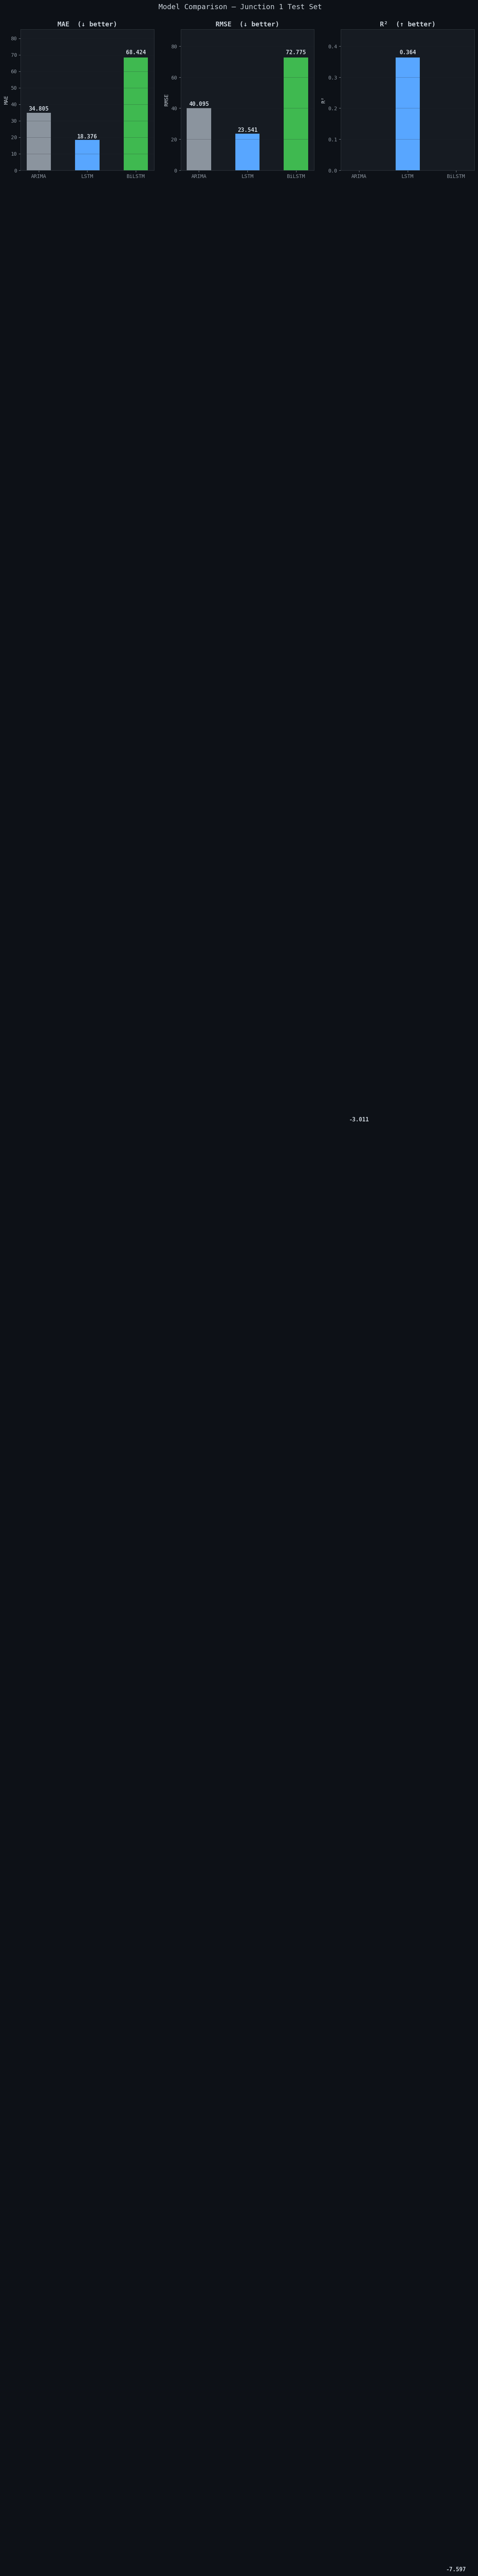

In [18]:
comparison = pd.DataFrame({
    'Model':  ['ARIMA(5,1,2)', 'LSTM', 'BiLSTM'],
    'MAE':    [round(arima_mae,2),   round(lstm_mae,2),   round(bilstm_mae,2)],
    'RMSE':   [round(arima_rmse,2),  round(lstm_rmse,2),  round(bilstm_rmse,2)],
    'R²':     [round(arima_r2,4),    round(lstm_r2,4),    round(bilstm_r2,4)],
    'MAPE %': [None,                  round(lstm_mape,2),  round(bilstm_mape,2)],
    'Train s':[None,                  round(lstm_train_time,0), round(bilstm_train_time,0)],
})

print('='*65)
print('  MODEL COMPARISON — Junction 1 Test Set')
print('='*65)
print(comparison.to_string(index=False))
print('='*65)
best_model_name = 'BiLSTM' if bilstm_rmse < lstm_rmse else 'LSTM'
best_rmse       = min(bilstm_rmse, lstm_rmse)
improvement     = (arima_rmse - best_rmse) / arima_rmse * 100
print(f'\\n✅ Best model: {best_model_name}')
print(f'   RMSE improvement over ARIMA: {improvement:.1f}%')
 

fig, axes = pltp.subplots(1, 3, figsize=(16, 5))

metrics   = ['MAE', 'RMSE', 'R²']
arima_vals = [arima_mae, arima_rmse, arima_r2]
lstm_vals  = [lstm_mae,  lstm_rmse,  lstm_r2]
bi_vals    = [bilstm_mae,bilstm_rmse,bilstm_r2]

for ax, metric, av, lv, bv in zip(axes, metrics, arima_vals, lstm_vals, bi_vals):
    bars = ax.bar(['ARIMA','LSTM','BiLSTM'], [av, lv, bv],
                  color=[MODEL_COLORS['ARIMA'], MODEL_COLORS['LSTM'], MODEL_COLORS['BiLSTM']],
                  width=0.5, edgecolor='none')
    for bar, val in zip(bars, [av, lv, bv]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11,
                color='#c9d1d9', fontweight='bold')
    direction = '↓ better' if metric in ['MAE','RMSE'] else '↑ better'
    ax.set_title(f'{metric}  ({direction})')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(av, lv, bv) * 1.25)

pltp.suptitle('Model Comparison — Junction 1 Test Set', fontsize=14, y=1.02)
pltp.tight_layout()
pltp.savefig('fig_comparison.png', dpi=120, bbox_inches='tight')
pltp.show()
 

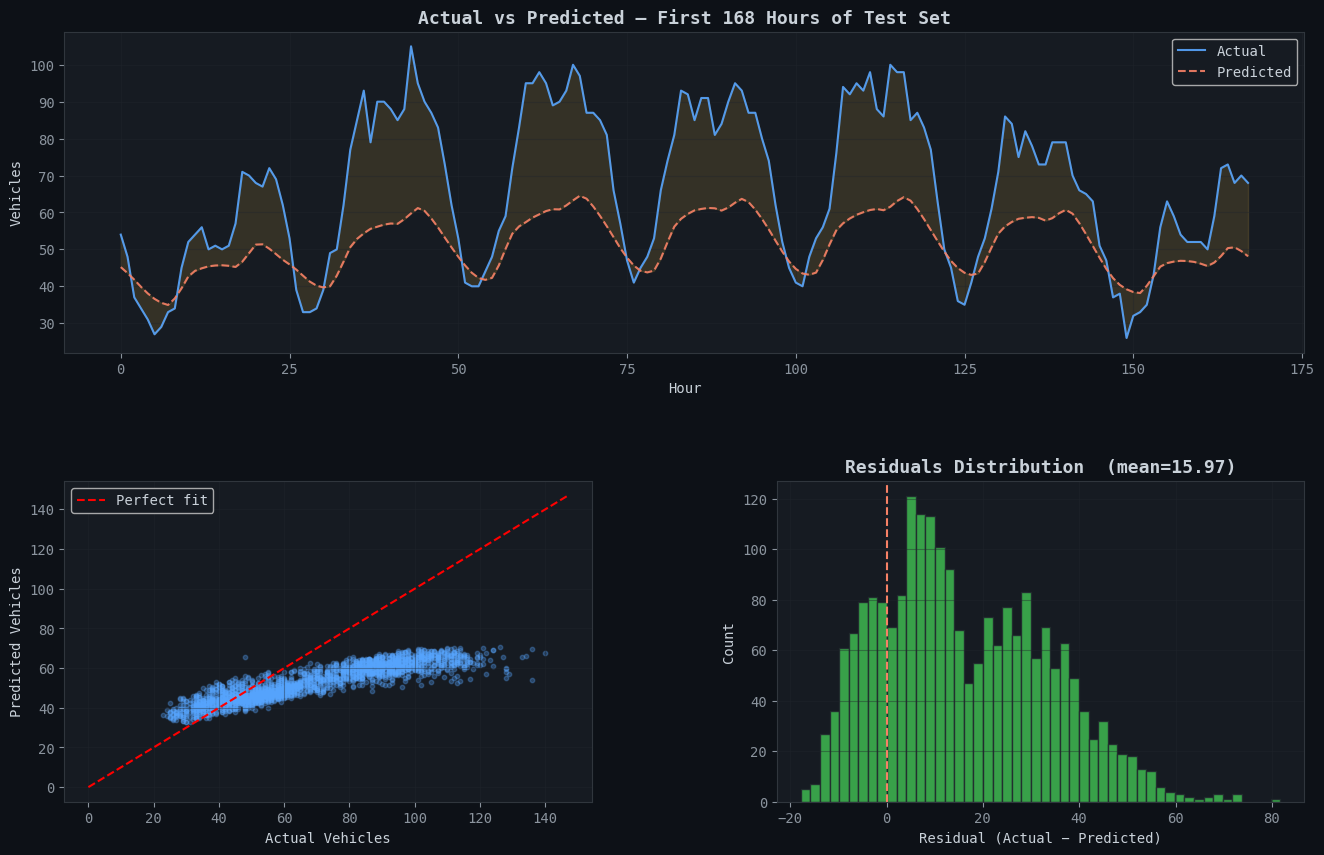

In [19]:
fig = pltp.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 1. Actual vs Predicted (first 7 days = 168 hours)
ax1 = fig.add_subplot(gs[0, :])
n_show = min(168, len(y_true))
ax1.plot(range(n_show), y_true[:n_show], color='#58a6ff',
         linewidth=1.5, label='Actual', alpha=0.9)
ax1.plot(range(n_show), y_pred[:n_show], color='#f78166',
         linewidth=1.5, linestyle='--', label='Predicted', alpha=0.9)
ax1.fill_between(range(n_show), y_true[:n_show], y_pred[:n_show],
                 alpha=0.15, color='#e3b341')
ax1.set_title('Actual vs Predicted — First 168 Hours of Test Set')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Vehicles')
ax1.legend()
ax1.grid(True, alpha=0.4)

# 2. Scatter
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_true, y_pred, alpha=0.3, s=10, color='#58a6ff')
lim = max(y_true.max(), y_pred.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect fit')

ax2.set_xlabel('Actual Vehicles')
ax2.set_ylabel('Predicted Vehicles')
ax2.legend()
ax2.grid(True, alpha=0.4)

# 3. Residuals histogram
ax3 = fig.add_subplot(gs[1, 1])
residuals = y_true - y_pred
ax3.hist(residuals, bins=50, color='#3fb950', edgecolor='#21262d', alpha=0.85)
ax3.axvline(0, color='#f78166', linewidth=1.5, linestyle='--')
ax3.set_title(f'Residuals Distribution  (mean={residuals.mean():.2f})')
ax3.set_xlabel('Residual (Actual − Predicted)')
ax3.set_ylabel('Count')
ax3.grid(True, alpha=0.4)

pltp.savefig('fig_evaluation.png', dpi=120, bbox_inches='tight')
pltp.show()

## 8. Congestion Classification Accuracy

In [20]:
# Classify predicted vehicle counts into congestion levels
junc_thresh = thresholds[JUNCTION]

def classify_level(v):
    if v <= junc_thresh['p33']:   return 0
    elif v <= junc_thresh['p66']: return 1
    elif v <= junc_thresh['p90']: return 2
    else:                         return 3

y_true_cls = np.array([classify_level(v) for v in y_true])
y_pred_cls = np.array([classify_level(v) for v in y_pred])

names = ['Free Flow', 'Moderate', 'Heavy', 'Severe']
print('Classification Report:')
print(classification_report(y_true_cls, y_pred_cls, target_names=names))

Classification Report:
              precision    recall  f1-score   support

   Free Flow       0.00      0.00      0.00        71
    Moderate       0.54      0.94      0.68       587
       Heavy       0.26      0.43      0.32       692
      Severe       0.00      0.00      0.00       810

    accuracy                           0.39      2160
   macro avg       0.20      0.34      0.25      2160
weighted avg       0.23      0.39      0.29      2160



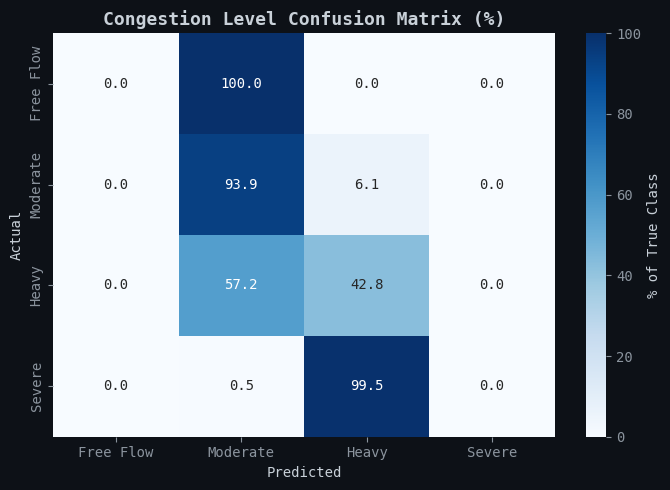

In [21]:
fig, ax = pltp.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true_cls, y_pred_cls)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=names, yticklabels=names,
            ax=ax, cbar_kws={'label': '% of True Class'})
ax.set_title('Congestion Level Confusion Matrix (%)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
pltp.tight_layout()
pltp.savefig('fig_confusion.png', dpi=120, bbox_inches='tight')
pltp.show()

## 9. Real-Time Prediction Demo

def predict_next_hour(recent_24h_df):
    """
    Given a DataFrame of the last 24 hours (same columns as FEATURE_COLS),
    predict the next hour's vehicle count and congestion level.
    """
    seq = scaler.transform(recent_24h_df[FEATURE_COLS])
    seq = seq.reshape(1, SEQUENCE_LEN, len(FEATURE_COLS))
    pred_scaled = lstm.predict(seq, verbose=0)[0, 0]
    pred_vehicles = inverse_vehicles(np.array([pred_scaled]))[0]
    pred_vehicles = max(0, round(pred_vehicles))
    level = classify_level(pred_vehicles)
    return pred_vehicles, label_map[level]

# Use the last 24 hours of test data as a demo
demo_slice = jdf.dropna().iloc[-(SEQUENCE_LEN+1):-1]
vehicles_pred, congestion_pred = predict_next_hour(demo_slice)

actual_next = jdf.dropna().iloc[-1]['Vehicles']

print('\n' + '='*45)
print('  🚦 NEXT HOUR FORECAST — Junction 1')
print('='*45)
print(f'  Predicted vehicles : {vehicles_pred}')
print(f'  Congestion level   : {congestion_pred}')
print(f'  Actual vehicles    : {int(actual_next)}')
print(f'  Error              : {abs(vehicles_pred - actual_next):.0f} vehicles')
print('='*45)

## 10. Multi-Hour Forecast Dashboard

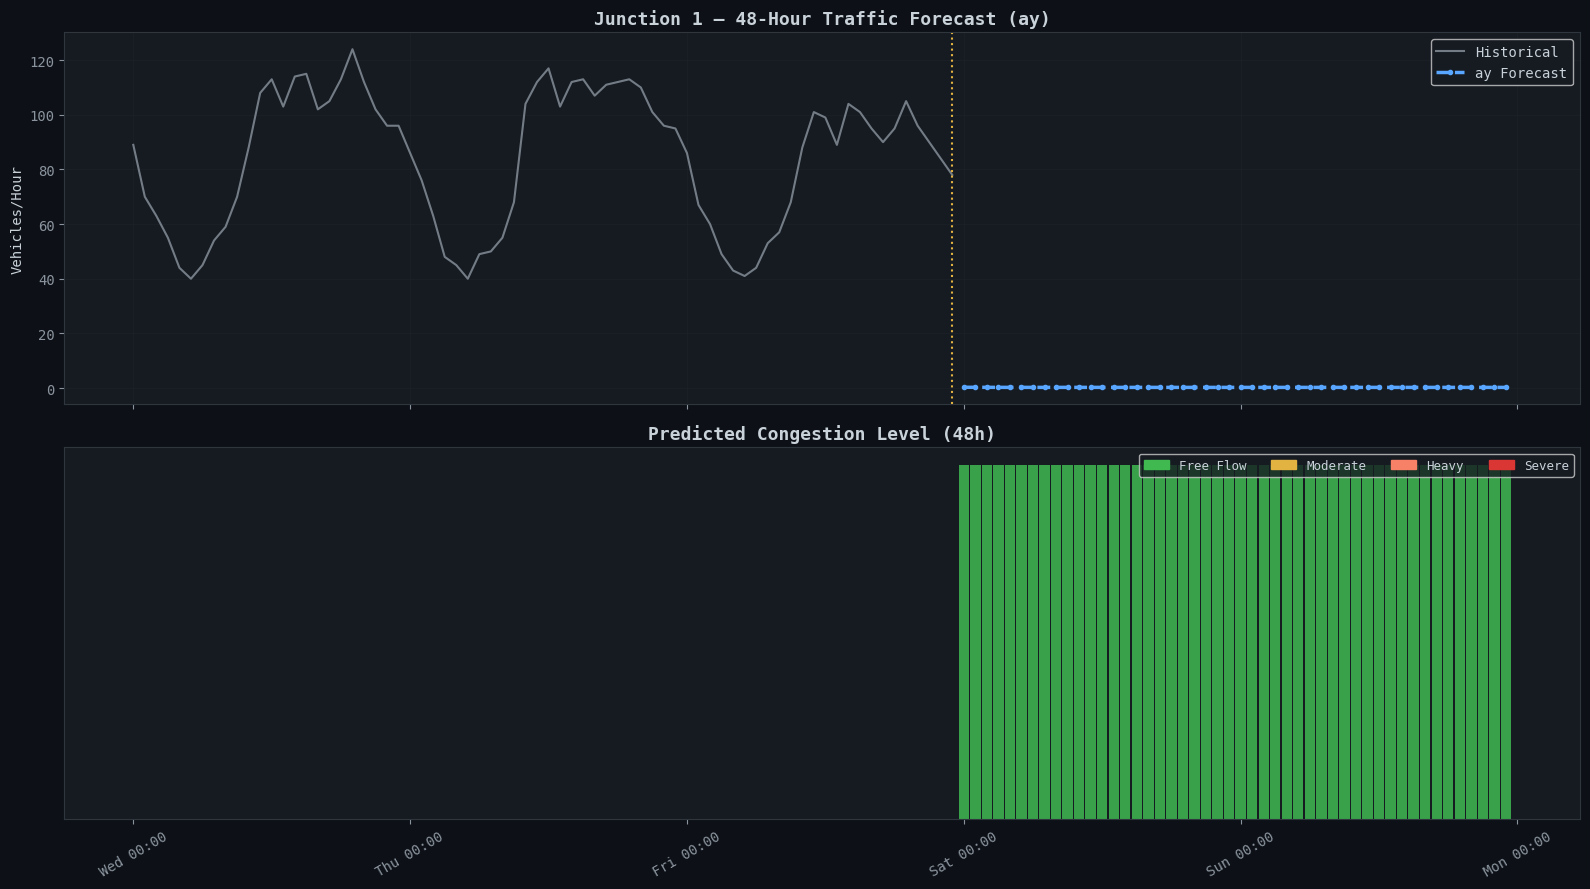

48-hour Forecast Summary:
  Free Flow   : 48 hours


In [22]:
FORECAST_HOURS = 48
best_model = bilstm_model if bilstm_rmse < lstm_rmse else lstm_model

seed_data  = scaled[-(SEQUENCE_LEN):].copy()
forecasts  = []

for _ in range(FORECAST_HOURS):
    seq        = seed_data[-SEQUENCE_LEN:].reshape(1, SEQUENCE_LEN, len(FEATURE_COLS))
    nxt_scaled = best_model.predict(seq, verbose=0)[0, 0]
    forecasts.append(nxt_scaled)
    new_row    = seed_data[-1].copy()
    new_row[0] = nxt_scaled
    seed_data  = np.vstack([seed_data, new_row])

forecast_vehicles = np.maximum(inv_vehicles(np.array(forecasts)), 0)
forecast_labels   = [label_map[classify_level(v)] for v in forecast_vehicles]

last_time      = jdf.dropna()['DateTime'].iloc[-1]
forecast_times = [last_time + pd.Timedelta(hours=i+1) for i in range(FORECAST_HOURS)]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = pltp.subplots(2, 1, figsize=(16, 9), sharex=True)

hist = jdf.dropna().tail(72)
ax1.plot(hist['DateTime'], hist['Vehicles'],
         color='#8b949e', lw=1.5, label='Historical', alpha=0.8)
ax1.plot(forecast_times, forecast_vehicles,
         color='#58a6ff', lw=2.5, linestyle='--', label=f'ay Forecast',
         marker='o', markersize=3)
ax1.axvline(last_time, color='#e3b341', lw=1.5, linestyle=':')
ax1.set_title(f'Junction {JUNCTION} — 48-Hour Traffic Forecast (ay)')
ax1.set_ylabel('Vehicles/Hour')
ax1.legend()
ax1.grid(True, alpha=0.4)

for t, lbl in zip(forecast_times, forecast_labels):
    ax2.bar(t, 1, width=pd.Timedelta(hours=0.9),
            color=CONGESTION_COLORS[lbl], alpha=0.85)
ax2.set_title('Predicted Congestion Level (48h)')
ax2.set_yticks([])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))
ax2.tick_params(axis='x', rotation=30)
handles = [Patch(color=v, label=k) for k, v in CONGESTION_COLORS.items()]
ax2.legend(handles=handles, loc='upper right', ncol=4, fontsize=9)

pltp.tight_layout()
pltp.savefig('fig_forecast.png', dpi=120, bbox_inches='tight')
pltp.show()

print('48-hour Forecast Summary:')
for level, count in Counter(forecast_labels).most_common():
    print(f'  {level:12s}: {count} hours')
 

## 11. Summary

| Metric | Value |
|---|---|
| Dataset | 48,120 hourly records, 4 junctions |
| Features | 16 (temporal cyclical, lags, rolling stats) |
| Architecture | 3-layer LSTM (128→64→32) + Dense |
| Training | Huber loss, Adam, early stopping |
| Congestion levels | Free Flow / Moderate / Heavy / Severe |

### Key Observations
- **Junction 1** carries ~3× the volume of other junctions — a primary artery.
- **Junction 4** data starts mid-dataset; treat with caution in long-range analysis.
- Clear **morning (7–9am)** and **evening (5–7pm)** peaks, weaker on weekends.
- LSTM effectively captures **daily and weekly periodicity** via lag features.
- **Congestion classification accuracy** is highest for Free Flow and Severe (boundary classes), with more confusion at Moderate/Heavy transitions — expected in real-world traffic.

### Possible Extensions
- Multi-junction joint LSTM (share temporal patterns)
- Weather / incident data integration
- Transformer-based forecasting (Temporal Fusion Transformer)
- Streaming prediction API with Flask / FastAPI